# Chromatin structure inference from probabilistic modeling of

eigenvectors from Hi-C data analysis in a Bayesian framework

Modeling eigenvectors from Hi-C analysis with spatial depency in a Gaussian Random Walk and infering a latent compartment assignment to A or B as an excuse to master PyMC

Søren Jørgensen (Aarhus University)  
August 19, 2025

Here, I aim to do probabilistic modeling of eigenvectors obatained from the ICE method in Hi-C analysis. The idea is to capture some of the variance lost when hard-labeleling the bins based on only the *sign* of the eigenvector.

This model infers A/B chromatin compartment structure from the first eigenvector (E1) of the Hi-C contact matrix using a Bayesian framework.

**Goals**

-   Replace hard sign-thresholding of E1 with a probabilistic compartment assignment.
-   Quantify uncertainty in compartment calls for each genomic bin.
-   Allow for modeling of missing E1 values due to low signal.

**Assumptions**

-   Each bin belongs to one of two latent states: A or B compartment.
-   E1 values are generated from Gaussian distributions specific to each compartment.
-   Prior belief: A has positive E1 values ($\mu = 0.5$), B has negative ($\mu = -0.5$).
-   Bins are initially treated as independent
-   Spatial depency are added later (Gaussian Random Walk)

# Introduction

Chromatin architecture is of high interest in molecular biology, and increasingly so in molecular evolution. A high-throughput method for mapping the 3D organization of the genome was proposed by Lieberman-Aiden et al. ([2009](#ref-lieberman-aiden2009comprehensivemappinglongrange)), and has since been the standard method of infering chromatin compartments ([Lajoie, Dekker, and Kaplan 2015](#ref-lajoie2015hitchhikersguidehic)). Briefly, chromatin interactions from Hi-C sequencing is used to generate an interaction matrix of valid Hi-C contacts, and PCA is performed on the covariance matrix of the observed/expected matrix. The following rationale is proposed and experimentally supported; if clustering into 2 types (A/B compartments), genomic positions that interact will yield a positive value in the covariance matrix, and vice versa for positions that do not interact. Then, when PCA is performed, the first principal component captures the variance that arise from being in different compart by its sign. The direction of the eigenvector (the sign) is then phased with a biologically relevant measure (such as GC content) to establish that the A compartment is largely the *active* chromatin and B is largely *inactive*.

However, this approach may place too much confidence in how expected interaction frequencies are estimated. By using the eigenvectors within a probabilistic model, where compartment identity is treated as a latent variable, we aim to recover information discarded in hard-labeling based on eigenvector signs. We propose a Bayesian MCMC framework as a spatially aware clustering method that soft-assigns compartments based on the eigendecomposition by assuming that the magnitude of the eigenvector is significant.

## Bayesian Statistics and modeling

I Bayesian statistics, a prior belief, $P(\theta)$ is combined with the likelihood of observed data, $P(D|\theta)$, to achieve a posterior probability, $P(\theta|D)$, as Bayes’ Theorem formulates in

<span id="eq-bayes-theorem">$$ 
P(\theta | D) = \frac{P(D \ | \ \theta) \ P(\theta)}{P(D)}.
 \qquad(1)$$</span>

To make a proper probability distribution of the posterior, we use the marginal likelihood,

<span id="eq-marginal-likelihood">$$
P(D) =\int P(D \ | \ \theta) \ P(\theta) \ \mathrm{d}\theta,
 \qquad(2)$$</span>

which integrates the likelihood over all possible parameter values, weighted by the prior. However, $P(D)$ is often high-dimensional and therefore intractable to evaluate analytically. Therefore, we can estimate **posterior properties** without explicitly computing $P(D)$ by **sampling from the posterior** using *Markov Chain Monte Carlo* (MCMC) methods.

MCMC avoids the daunting integral by constructing a Markov chain \[ref\] with a stationary distribution $P(\theta|D)$. Then, after a burn-in period, the samples, $\theta^{(1)}, \dots, \theta^{(N)}$, can be used to approximate the expectation:

<span id="eq-mcmc-expectation">$$
\mathbb{E} \left[ f(\theta) \ | \ D \right] \approx \frac{1}{N}\sum_{i=1}^N f \left ( \theta^{(i)} \right ).
 \qquad(3)$$</span>

This enables us to perform inference in models without analytical evaluation.

## Continuing from where we left

This study is a continuation of *Chromatin Compartments and Selection on X* (MSc thesis) \[ref\] and some methods were developed there. Especially, one product of the previous study was a pipeline to generate eigenvectors for binned genomes from raw Hi-C reads, utilizing *pairtools* \[ref\] *cooler* \[ref\] and *cooltools* \[ref\] from the *Open Chromosome Collective* ecosystem \[ref\].

> NB: limitations of using the magnitude of the eigenvector in opposite to only the sign

# Methods

```` markdown
```{python}
import pymc as pm
import pytensor.tensor as pt

print(pm.__version, pt.__version__)
```
````

The pipeline from \[ref\] was reused in a modified form to accomodate a new data set of single-cell Hi-C sequencing of human cells. Here, an additional pooling step was introduced to generate merged Hi-C matrices after grouping the samples into two groups established in the sequencing study; the sex chromosome was determined either *X* or *Y*. Additionally, it was modified to accomodate the new telomere-2-telomere assembly of *Macaca mulata*, as it was only available from NCBI, and not UCSC servers.

## Data generation

### The ICE-method

The pipeline previously developed implements the Iterative Correction and Eigendecomposition (ICE) method of Hi-C analysis ([Lieberman-Aiden et al. 2009](#ref-lieberman-aiden2009comprehensivemappinglongrange)) after mapping raw Hi-C reads to the reference genome, validating Hi-C pairs, and constructing the interaction map (Hi-C matrix). It is implemented fully using the *Open2C* tools and recommendations. Briefly, the raw read pairs are mapped (as paired-end reads) to the respective reference genome (either GRCh37 or T2T-MMU8v1.0) with *bwa-mem2* \[ref\] with the `-P` option. Then the pairs are parsed and sorted with *pairtools*, and a deduplication and quality filter ($mapq \geq 30$) is run to remove PCR duplicates and technical noise from low-quality reads. Lastly, the binned interaction matrices (`.cool` files, hence also *coolers*) are created from the remaining pairs into the base-resolution of 1kb bins that is then recursively coarsened until 1 Mb bins. The resulting raw interaction matrices do not have a uniform coverage profile along the genome as a result of differential binding or accesibility of the restriction enzyme and other technical factors. High or low coverage is visible in the interaction matrices, where genomic regions will appear as highly or weakly interacting regions even though they are artefacts of the coverage. Thus, it is needed to balance the interaction counts to avoid *visibility-induced biases* \[ref\]; it is time for ICE.

The interaction counts of each bin is corrected iteratively until convergence of the coverage, and the correction weight is saved to the cooler. The expected interaction matrix is derived from the decay in contact probability over genomic distance (also; distance decay), and is used to scale the observed interactions before performing eigendecomposition on the correlation matrix of observed/expected. Bins interacting with bins of the same type should keep a positive eigenvector, and vice versa otherwise. Thus, the first principal component *should* capture the variance explained by the compartment assignment. The eigenvectors are then oriented to correlate with GC content, to ensure that positive values represent A-compartments and active chromatin, and negative values represent B-compartments and inactive chromatin.

As also described in \[ref\], sometimes there is a larger amount of variance in interaction frequency between chromosome arms than within arms. In these cases, the eigendecomposition will not capture the compartments, but only change its sign at the centromere. Thus, it is a safe practice to do the eigendecomposition on the chromosome arms separately, and is readily implemented into *cooltools* by providing a viewframe to the function that does the calculations. It is not clear how further experimentation with narrowing the eigendecomposition viewframe affects the biological explanation of the results, but it is suggested as a method of obtaining more local compartmentalization ([Wang et al. 2019](#ref-wang2019reprogrammingmeioticchromatin)) (termed local PCA). As no centromere was available from the T2T-MMU8v1.0, it was inferred from the largest cluster of sattelite repeats, approximately between 57 Mp and 69 Mp (<a href="#fig-t2t-satellites" class="quarto-xref">Figure 1</a>).

``` python
plot_intervals(satellites, lw=0.3, alpha=1)
```

<figure id="fig-t2t-satellites">
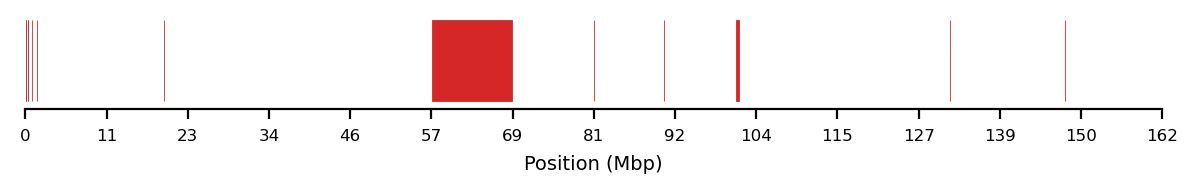
<figcaption>Figure 1: Satellite repeats on chrX, inferred from <code>repeatMasker</code> file from the T2T-MMU8v1.0 assembly. The centromere is locdated at the largest cluster of satellite repeats, merging intervals within 20kb.</figcaption>
</figure>

First, the pipeline was applied to generate high-resolution eigenvector tracks on the most recent, telomere-to-telomere *Macaca mulata* assembly, T2T-MMU8v1.0 \[ref\], to improve the accuracy of the mapping from the previous study.

Additionally, the pipeline was applied to generate a eigenvectors of human sperm cells harboring the *X* chromosome. Even though the authors \[ref\] of this Hi-C data find high similarity between sperm cells harboring the *X* or the *Y* sex chromosomes, they barely describe their comparison. Thus, I decide to seperate them into two groups to be able to compare autosomal chromatin compartments later on if we wish to. A major downside of this is that the coverage is approximately halved, resulting in lower viable resolutions for subsequent analyses.

The results of the eigendecomposition are hereafter described as E1 (eigenvector track of the first principal component).

## Modeling

I use PyMC ([Abril-Pla et al. 2023](#ref-abril-pla2023pymcmoderncomprehensive)) for all modeling, relying as much as possible on functions and built-in functionality for all anaysis. I start out small in the simplest model possible, then progressing to larger and more complex models. The basis of the probabilistic modeling is the assumption that the eigenvectors of A- and B-compartments can be drawn from distinct distributions. I assume that the distributions underlying the compartments are Gaussian with different means, either $\mu_a = 0.5$ or $\mu_b = -0.5$. Additionally, I assume that a probability of being in A can be inferred from the eigenvector, and that a binary latent state can be derived from that to place compartment labels on each bin (I call that `z`).

I experimented with the possibility of marginalizing over the binary latent state to make sampling faster, as the No-U-Turn-Sampler (NUTS) \[ref\] can only sample from continuous variables, and the *BinaryGibbsMetropolis* sampler is significantly slower. PyMC notes some builtin automatic marginalization of discrete variables \[ref\], but the example used does not directly translate into my case. Therefore, a continuous mixture model of the two underlying Gaussians were tried to test sampling efficiency or differences. Here, in stead of using compartment type as a latent random variable switch (“choose A or B”), an assignment probability was used as a mixing weight for the two Gaussians. Note that the switch can be modeled in to distinct ways; one where it is a fitted random variable (probabilistic), or as a literal switch with an `if`-statement (deterministic). In reality, both methods cause the sampling distribution space to be discrete, making them unfit for the NUTS sampler, even though the deterministic switch *can* be implemented with NUTS. Though the continous mixture model is much faster (\>20x), I reflect that the underlying biological assumptions about compartment identity is also marginalized (largely lost) when dropping the hard type assignment. With that in mind, I fitted models both with and without the latent assignment.

When taking advantage of PyMC’s vectorization capabilities, a single variable `mu` can be defined with an array of $\mu$’s for respective distributions. That is, we can define

```` markdown
```{python}
mu = pm.Normal('mu', mu=[-0.5, 0.5], sigma=sigma, shape=2)
```
````

Here, `shape=2` is not necessary as it is implicit from the shape of the `mu`-parameter, but adds clarity. For even more clarity, we can define the coordinates underlying the model and then pass it to the variable, as with `coords = {'label': ['B', 'A']}` and passing `dims=label` in stead of `shape=2`. Additionally, to prevent the distributions leaking into each other, I apply an `ordered.transform` to the variable, ensuring that the first of the 2 draws will be lower than the next.

### Model 1: Spatially independent (i.i.d.)

The simplest modeling approach is by regarading each of the bins independent of each other, and to simply draw from one of the distributions based on the encountered E1 value. The probability, $p$ of being in A is determined using a flat prior, $Beta(1,1)$, which is assigned to a type, $z$, with a Bernoulli trial on $p$. Additionally, the two distributions have a shared standard deviation out of a HalfNormal distribution, $\sigma \sim \mathcal{HN}(1)$. That is,

<span id="eq-simple_iid_model">$$
\begin{aligned}
\mu_A &\sim \mathcal{N}(0.5, 0.5) \\
\mu_B &\sim \mathcal{N}(-0.5, 0.5) \\
\sigma &\sim \mathcal{HN}(1) \\
p &\sim \text{Beta}(a, b)\\
z_i &\sim \text{Bernoulli}(p) \\
\mu_i &= 
\begin{cases}
\mu_A & \text{if } z_i = 1 \\
\mu_B & \text{if } z_i = 0
\end{cases} \\
y_i &\sim \mathcal{N}(\mu_i, \sigma) \\
\end{aligned}
 \qquad(4)$$</span>

where $y_i$ is the observed E1 value at bin $i$, $z_i \in \{0, 1\}$ is the latent compartment assignment (0 = B, 1 = A). 8 chains of 1000 samples (and $8x1000$ tuning samples) results in 8000 posterior samples after the model has run.

The model might be able to fit well to the observed data, but it is unlikely that it can generalize. Here it is as a Mermaid-js diagram, embedded from the Mermaid-representation built into PyMC.

``` python
from mermaid.graph import Graph
from mermaid import Mermaid
from IPython.display import Image


mermaid_graph = Graph("Simple i.i.d", 
                      pm.model_to_mermaid(model, include_dim_lengths=False)
)


render = Mermaid(mermaid_graph, position="center")

# png_path = "../thesis/illustrations/simple_iid_model.png"
# render.to_png(png_path)
# Image(png_path)

Image(render.img_response.content)
```

<figure id="fig-simple_iid_model">
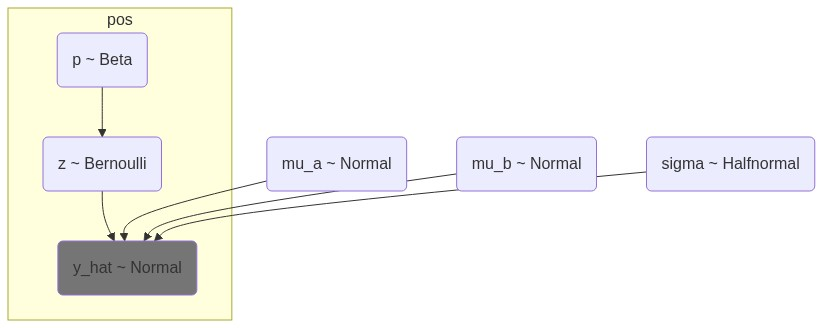
<figcaption>Figure 2: Simple i.i.d. model for E1 values. <code>p</code> is the probability of a bin being in compartment A, <code>z</code> is the latent state variable indicating whether a bin is A or B, and <code>mu_a</code> and <code>mu_b</code> are the expected means for A and B compartments, respectively. The model assumes that the E1 values are normally distributed around these means with a shared standard deviation <code>sigma</code>.</figcaption>
</figure>

### Model 2: Spatially dependent (Random Walk)

To take into account the autocorrelation along the positional axis, I implement a Gaussian Random Walk (GRW) in the logit space of the compartment assignment. That is, the steps between each assignment probability is restricted with a random walk from a bin `i` to the next bin `i+1`. In stead of drawing the compartment probability, $p$, from a flat prior directly, some new variables are introduced. A GRW is effectively the cummulative sum of steps along the positional axis, and can be defined as centered or non-centered \[ref\]. The centered version is pre-implemented in PyMC as `pymc.GaussianRandomWalk` \[ref\], taking a `sigma` parameter for standard deviation. In the centered GRW the step size and standard deviations are exploring parameter space together and might ot explore it as efficiently or as quickly as a non-centered model that samples the two parameters independently. On the other hand, the non-centered model might interact more with hyperparameters and data. Better results achieved from a non-centered model might indicate that the data is not informative enough for the tighter restrictions on the posterior emposed by the centered model

#### Centered GRW

The new variables `grw_sigma` was sampled from a Half-Normal distribution and given to the `logit_p` that models the GRW with `pymc.GaussianRandomWalk`. As noted, both variables explore parameter space together. Then, the logits are converted to probabilities, $p$, by squishing them through a sigmoid, and finally, the compartment is assigned as in the *i.i.d.* model by a Bernoulli trial.

<span id="eq-centered-grw">$$
\begin{aligned}
\mu_A &\sim \mathcal{N}(0.5, 0.5) \\
\mu_B &\sim \mathcal{N}(-0.5, 0.5) \\
\sigma &\sim \mathcal{HN}(1) \\
\sigma_{\mathrm{GRW}} &\sim \mathcal{HN}(0.01)\\
\mathrm{logit}_p &\sim \operatorname{GaussianRandomWalk}(\sigma_{\mathrm{GRW}}) \\
p &= \operatorname{sigmoid}(logit_w) \\
z_i &\sim \text{Bernoulli}(p) \\
\mu_i &= 
\begin{cases}
\mu_A & \text{if } z_i = 1 \\
\mu_B & \text{if } z_i = 0
\end{cases} \\
y_i &\sim \mathcal{N}(\mu_i, \sigma) \\
\end{aligned}
 \qquad(5)$$</span>

#### Non-centered GRW

There are different opinions on when to reparameterize a centered model into a non-centered model \[ref\], but in my case, PyMC suggested a reparameterization. The idea is to fit the parameters independently and thus achieve a less restricted exploration of parameter space. In this case, the random walk is modeled as follows: the step size is a separate variable, `eps`, drawing from a standard Gaussian distribution. Then, the step size is scaled by `grw_scale` which is drawn from a HalfNormal when adding the each step to the random walk by cummulative summation. Again, the walk is constructed in logit space, $\mathrm{logit}_w$, and forced through a sigmoid to obtain assignment probabilities, and finally, the assignment is performed with a Bernoulli trial on $w$:

<span id="eq-non-centered-grw">$$
\begin{aligned}
\mu_A &\sim \mathcal{N}(0.5, 0.5) \\
\mu_B &\sim \mathcal{N}(-0.5, 0.5) \\
\sigma &\sim \mathcal{HN}(1) \\
\sigma_{\mathrm{GRW}} &\sim \mathcal{HN}(0.01)\\
\epsilon_{\mathrm{GRW}} &\sim \mathcal{N}(0, 1) \\
\mathrm{logit}_{w_i} &= \sum_{k=1}^i \epsilon_{\mathrm{GRW}, k} \, \sigma_{\mathrm{GRW}} \\ 
z_i &\sim \text{Bernoulli}(p) \\
\mu_i &= 
\begin{cases}
\mu_A & \text{if } z_i = 1 \\
\mu_B & \text{if } z_i = 0
\end{cases} \\
y_i &\sim \mathcal{N}(\mu_i, \sigma) \\
\end{aligned}
 \qquad(6)$$</span>

## Evaluations

To be able to comparatively evaluate the models, we must establish exactly what we are modeling. The biological assumptions we make is that **1)** a given genomic region can be one type at a time, and **2)** the autocorrelation between intervals along the genome can be modeled by probabilistic smoothing of the E1 track, even at 10kb resolution. The goal is not to discover new compartments, but to model the transitions between compartments with the assumption that some peaks or dips in E1 that barely causes a sign change are potentially caused by noise and are thus not of biological relevance. Of course, the ability to model this behaviour relies heavily on the assumption that the value of the E1 track carries information about the distinction between compartments additional to that of the sign of the vector.

In a classical setting, the way to compare Bayesian models is by *some* measure of how much *information* a model has learned from the data it was trained on. *Arviz* provides the *Akaike Information Criterion* (AIC) and the *Widely Applicable Information Criterion* (WAIC), where it uses leave-one-out cross-validation (LOO-CV) to generate the out-of-sample predictive accuracy. Conveniently, the `arviz.compare` takes multiple models and generates a neat table with the results of its cross-validation analysis.

However, when an expected result of the model is that some peaks or small compartments are reduced or smoothed, we must question the interpretability of these criteria. At least, the balance between generalization and fitting should be skewed towards generalization, expectedly at the cost of fitting. Additionally, there is some dispute around using CV for timeseries (or random walk models), as the left-out samples will affect the autocorrelated nature of the predictions [ref](https://statmodeling.stat.columbia.edu/2015/01/16/loo-waic-time-series/). However, it seems that when using CV for model comparison, the same bias is introduced in all the compared models, and can thus largely be ignored.

## Parameter sweep

## Resolutions and subsets

After initial evaluations of the foundational architecture was done by fitting 100kb resolution data, the same architecture was applied to higher resolution (10kb) data. That is, we assume the system of varables have the same relationship and can be drawn from the same distributions as the lower-resolution data. To achieve a comparable runtime, a subset of the data was selected from a 1500-bin interval that was qualitatively determined to have high variance. However, not only the resolution was exchanged, but also the data set. For the hi-res analysis, I used the GRCh37-mapped data set from human X-bearing sperm, and did no further investigation of the macaque data.

Initially, the selected subset was thought to have a good amount of variance, but upon further investigation, it could also be interpreted as a high level of noise compared to biological information. Therefore, the same model architecture was applied to the two chromatin arms seperately, and lastly the full X chromosome.

# Results

## The ICE

After remapping the macaque data to the T2T assembly, the eigentracks were calculated as described. They were visually evaluated at the different resolutions (fig-e1-sperm), showing the expected shifts in E1 values on the megabase scale for all resolutions except 1kb. This means that the sequencing was not sufficiently deep for binning Hi-C contacts into 1000 bp regions, and many bins has 0 or only a few contacts. To be sure to have informative enough data, the 10kb resolution was chosen for further analysis in probabilistic modeling. Factoring in the experience of Lajoie, Dekker, and Kaplan ([2015](#ref-lajoie2015hitchhikersguidehic)) that $100,000,000$ valid reads is sufficient for 40kb resolution without too much noise, this is still a rather optimistic choice, as we have only $\sim 12,500,000$ valid interactions from the sperm cells. However, this underlines the need for modeling the noise when fitting the models later.

``` python
alpha_list = [0.2, 0.2, 0.3, 0.7, 0.9] # Adjusted alpha for scatter points

for alpha,res in zip(alpha_list,['1000', '5000', '10000', '50000', '100000']):
    plot_eigenvectors(sperm_dict[res], title=None,
                      scatter=True, 
                      scatter_alpha=alpha)
```

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-display" width="100.0%" data-layout-align="left">
<figure id="fig-e1-sperm-1">
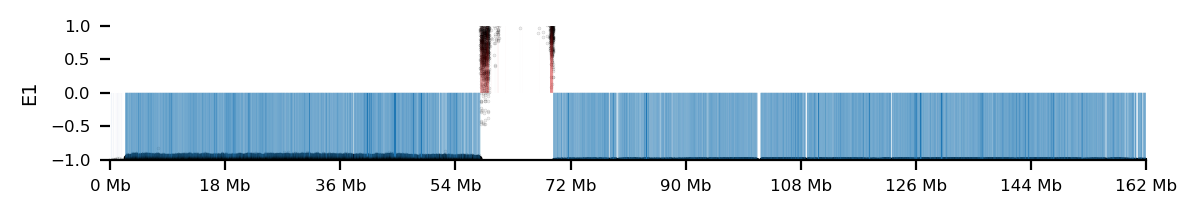
<figcaption>(a) Sperm E1 at 1kb resolution</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-display" width="100.0%" data-layout-align="left">
<figure id="fig-e1-sperm-2">
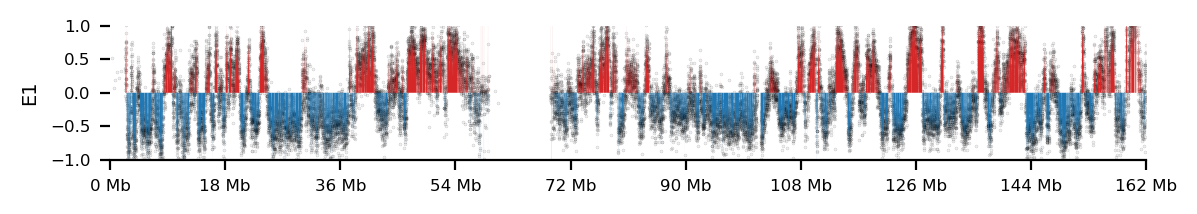
<figcaption>(b) Sperm E1 at 5kb resolution</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-display" width="100.0%" data-layout-align="left">
<figure id="fig-e1-sperm-3">
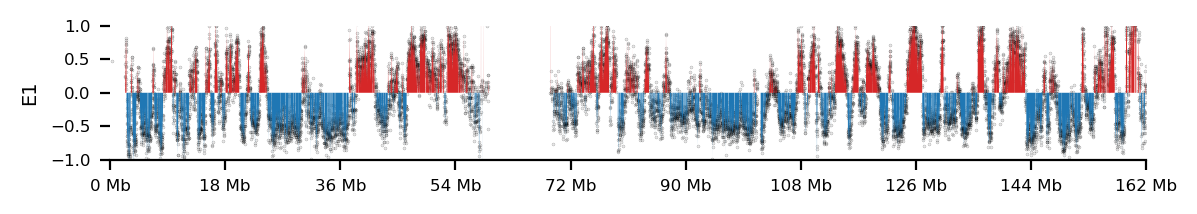
<figcaption>(c) Sperm E1 at 10kb resolution</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-display" width="100.0%" data-layout-align="left">
<figure id="fig-e1-sperm-4">
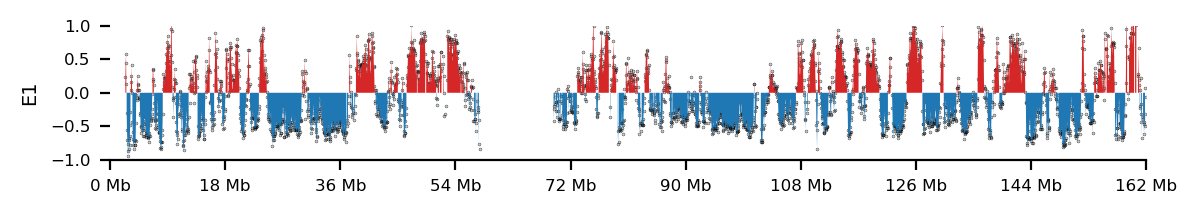
<figcaption>(d) Sperm E1 at 50kb resolution</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-display" width="100.0%" data-layout-align="left">
<figure id="fig-e1-sperm-5">
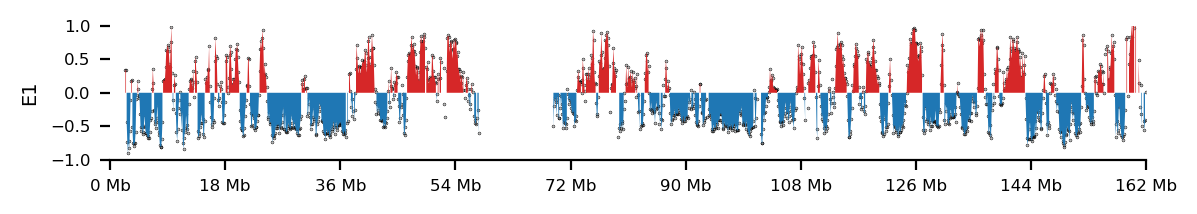
<figcaption>(e) Sperm E1 at 100kb resolution</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

Figure 3: E1 eigenvector for T2T-MMU8v1 sperm at different resolutions. The E1 eigenvector is the first eigenvector of the covariance matrix of the Hi-C contact matrix, and it captures the dominant mode of variation in the data. The classical definitions, A: E1 \> 0 and B: E1 \< 0, are shown in red and blue, respectively. E1 values are overlayed as scatter.

We were less confident in the human sperm data, as approximately half of the cells were filtered out compared to the original study (they had the Y chromosome), resulting in only $\sim 3,500,000$ valid interactions. This is evidently not sufficient for high-resolution analysis directly, visualized by the extreme noise level in fig-e1-sperm B) and C).

``` python
alpha_list = [0.2, 0.2, 0.3, 0.7, 0.9] # Adjusted alpha for scatter points

for alpha,res in zip(alpha_list,['1000', '5000', '10000', '50000', '100000']):
    plot_eigenvectors(sperm_X_dict[res], 
                      title=None,
                      scatter=True,
                      scatter_alpha=alpha)
```

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-display" width="100.0%" data-layout-align="left">
<figure id="fig-e1-sperm-x-1">
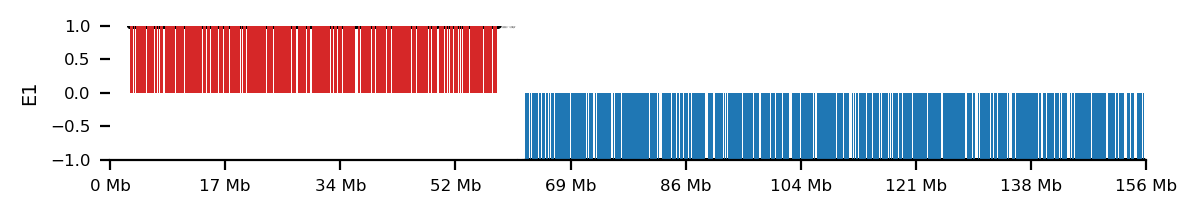
<figcaption>(a) 1kb resolution</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-display" width="100.0%" data-layout-align="left">
<figure id="fig-e1-sperm-x-2">
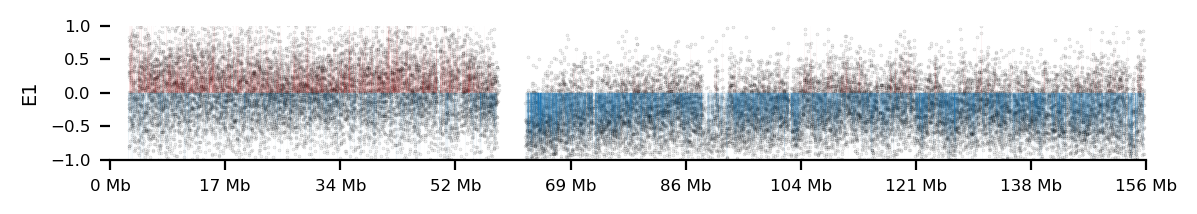
<figcaption>(b) 5kb resolution</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-display" width="100.0%" data-layout-align="left">
<figure id="fig-e1-sperm-x-3">
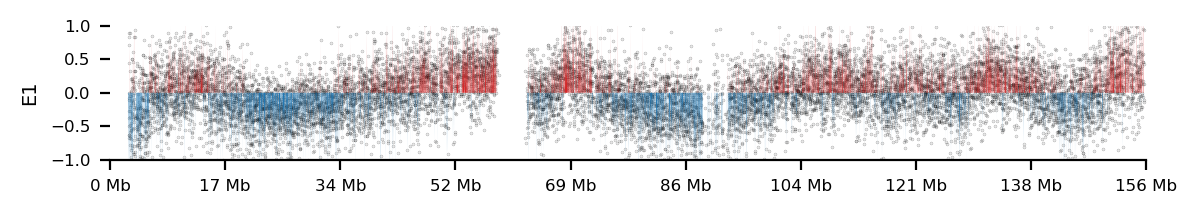
<figcaption>(c) 10kb resolution</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-display" width="100.0%" data-layout-align="left">
<figure id="fig-e1-sperm-x-4">
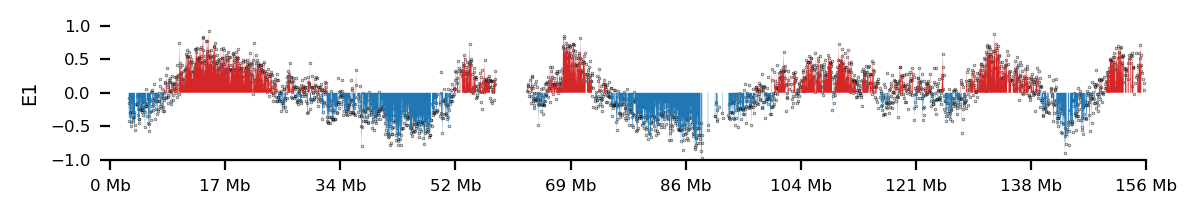
<figcaption>(d) 50kb resolution</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-display" width="100.0%" data-layout-align="left">
<figure id="fig-e1-sperm-x-5">
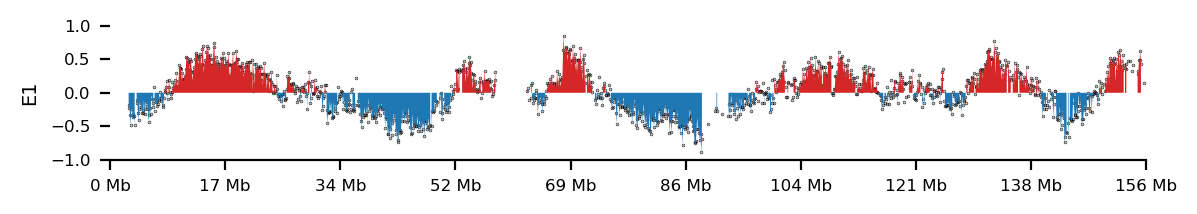
<figcaption>(e) 100kb resolution</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

Figure 4: E1 eigenvector for human GRCh37 sperm at different resolutions. The E1 eigenvector is the first eigenvector of the covariance matrix of the Hi-C contact matrix, and it captures the dominant mode of variation in the data. The classical definitions, A: E1 \> 0 and B: E1 \< 0, are shown in red and blue, respectively. E1 values are overlayed as scatter.

## The models

The best performing model on the 100kb data was re-fitted with the 10kb human data set. However, to get similar bin sizes, a subset of 1500 bins was taken from the E1 track. Additionally, the small chromatin was used as a subset, and lastly, the full chromosome X was fitted to the same model (same architecture).

``` python
import matplotlib.pyplot as plt

# Set matplotlib to display SVG format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

x = w_stack_z["pos"]

f, ax = plt.subplots(figsize=(6, 3))

ax.fill_between(
    x,
    w_ci_lower_direct,
    w_ci_upper_direct,
    alpha=0.3,
    label="95% CI",
    color="blue",
    ec='None'
)

x_grey = x.copy()
x_grey = x_grey.where(
    ~((w_mean < 1/3) | (w_mean > 2/3)), np.nan
    #~((w_ci_lower_direct < 1/3) & (w_ci_upper_direct < 1/3) | (w_ci_lower_direct > 2/3) & (w_ci_upper_direct > 2/3)), np.nan
)

# Grey band
ax.fill_between(
    x, 
    0,
    1,
    where=x_grey.notnull(),
    alpha=0.1,
    color='gray')

# Add the CI rule as text
ax.text(0.05, 0.95, "CI Rule: $1/3 < \\hat{w}_{post} < 2/3$", 
        transform=ax.transAxes, fontsize=7, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

# Plot the posterior mean
ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

# Plot the 0.5 line
ax.hlines(0.5, min(x), max(x), color="black", linestyle='dotted', linewidth=0.5)

# # Plot the CI rules
ax.hlines([0.33,0.66], min(x), max(x), color="red", linestyle=(0, (5, 10)), linewidth=0.5)

# Plot the crossing counts
ax.bar(x[:-1], crossing_density_up, label="A->B", color="tab:red", linewidth=0.3, alpha=0.7)
ax.bar(x[:-1], crossing_density_down, label="B->A", color="tab:blue", linewidth=0.3, alpha=0.5)

#  make x-axis tick x 10000 
ticks = np.linspace(0, len(x), num=6)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(tick/1000)}Mb" for tick in ticks])

plt.ylabel("w ; Crossing Density")
#plt.xlabel("Position (10kb bins)")
plt.legend(loc='lower right')
plt.title("Posterior Probability with Raw Mixing Weight CI and Crossing Density")
plt.tight_layout()
plt.show()
```

<figure id="fig-posterior-cross-dens-ci-w">
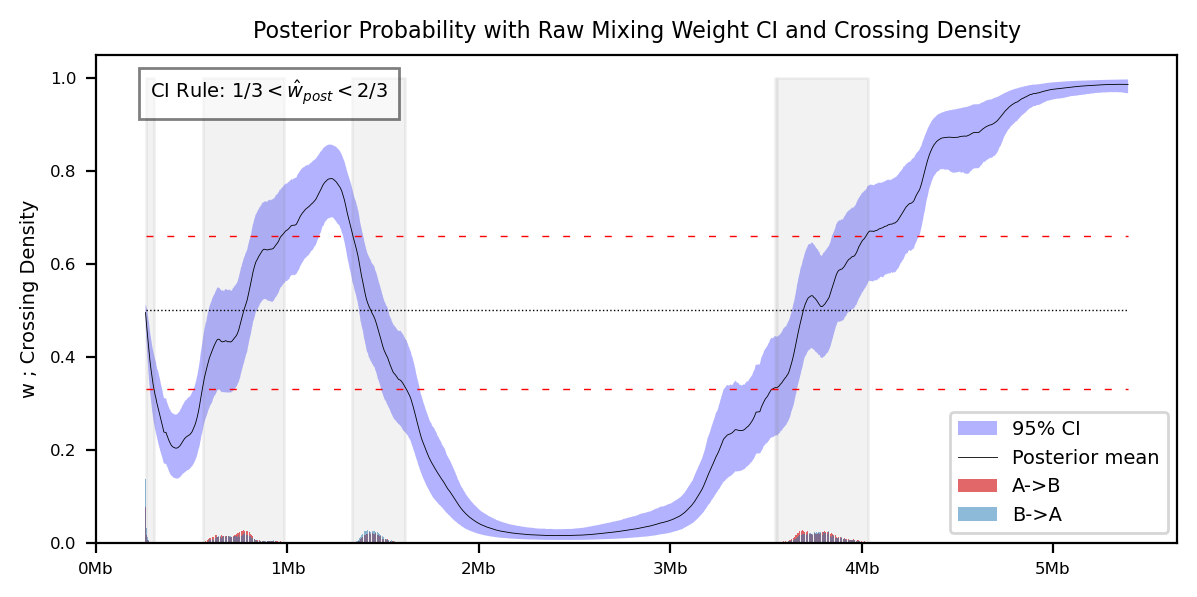
<figcaption>Figure 5: Posterior Probability with Raw Mixing Weight CI and Crossing Density. The CI rule used is <span class="math inline">\(1/3 &lt; \hat{w}_{post} &lt; 2/3\)</span>, as shown. The grey band indicates the regions where the CI rule is not satisfied. The crossing density bars show the number of crossings of the posterior mean at 0.5, with red indicating crossings upwards and blue indicating crossings downwards.</figcaption>
</figure>

# Discussion

The discussion

# Conclusion

I am concluding this analysis

# Bon mot

> Nothing in Biology Makes Sense except in the Light of Evolution
>
> \- Theodosius Dobzhansky

# References

Abril-Pla, Oriol, Virgile Andreani, Colin Carroll, Larry Dong, Christopher J. Fonnesbeck, Maxim Kochurov, Ravin Kumar, et al. 2023. “PyMC: A Modern, and Comprehensive Probabilistic Programming Framework in Python.” *PeerJ Computer Science* 9 (September): e1516. <https://doi.org/10.7717/peerj-cs.1516>.

Lajoie, Bryan R., Job Dekker, and Noam Kaplan. 2015. “The Hitchhiker’s Guide to Hi-C Analysis: Practical Guidelines.” *Methods (San Diego, Calif.)* 72 (January): 65–75. <https://doi.org/10.1016/j.ymeth.2014.10.031>.

Lieberman-Aiden, Erez, Nynke L. Van Berkum, Louise Williams, Maxim Imakaev, Tobias Ragoczy, Agnes Telling, Ido Amit, et al. 2009. “Comprehensive Mapping of Long-Range Interactions Reveals Folding Principles of the Human Genome.” *Science* 326 (5950): 289–93. <https://doi.org/10.1126/science.1181369>.

Wang, Yao, Hanben Wang, Yu Zhang, Zhenhai Du, Wei Si, Suixing Fan, Dongdong Qin, et al. 2019. “Reprogramming of Meiotic Chromatin Architecture During Spermatogenesis.” *Molecular Cell* 73 (3): 547–561.e6. <https://doi.org/10.1016/j.molcel.2018.11.019>.